In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

df = pd.read_csv('Midterm_53_group.csv')
df['Time_Sec'] = df['Time'].astype(int)
series = df.groupby('Time_Sec')['Length'].sum().values

log_series = np.log1p(series)

log_series = pd.Series(log_series).rolling(window=3).mean().dropna().values

def create_windows(data, window_size=15):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 30
X, y = create_windows(log_series, WINDOW_SIZE)
X = X.reshape(X.shape[0], X.shape[1], 1)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [6]:
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mae')

history = model.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test), 
    epochs=30, 
    batch_size=32, 
    verbose=1
)

Epoch 1/30


c:\Users\ananz\Network_intrusion_bot\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 7.1026 - val_loss: 6.2151
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 3.2696 - val_loss: 2.6473
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.4744 - val_loss: 1.6570
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.1719 - val_loss: 1.6872
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.3887 - val_loss: 1.2108
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.1513 - val_loss: 1.0684
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.0246 - val_loss: 0.9879
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9298 - val_loss: 1.0663
Epoch 9/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.9220 - val_loss: 0.9588
Epoch 10/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.8322 - val_loss: 0.8933
Epoch 11/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8006 - val_loss: 0.9554
Epoch 12/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7869 - val_l

## Result Visualization

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


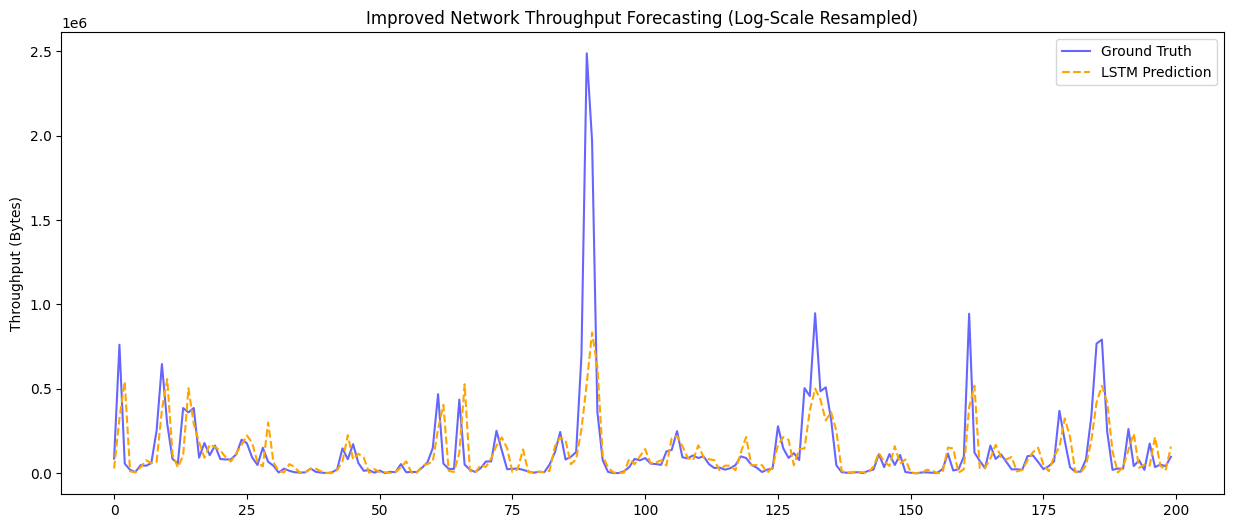

In [7]:
predictions = model.predict(X_test)

pred_inv = np.expm1(predictions)
true_inv = np.expm1(y_test)

plt.figure(figsize=(15, 6))
plt.plot(true_inv[:200], label='Ground Truth', color='blue', alpha=0.6)
plt.plot(pred_inv[:200], label='LSTM Prediction', color='orange', linestyle='--')
plt.title('Improved Network Throughput Forecasting (Log-Scale Resampled)')
plt.ylabel('Throughput (Bytes)')
plt.legend()
plt.show()

In [11]:
THRESHOLD = series.mean() * 2

forecast = pred_inv[-1][0]

print(f"Next Second Forecast: {forecast:,.2f} Bytes")
print(f"Current Threshold: {THRESHOLD:,.2f} Bytes")

if forecast > THRESHOLD:
    print("ALERT: Network congestion predicted in the next second!")
else:
    print("Prediction: Traffic is within normal range.")

Next Second Forecast: 27,246.84 Bytes
Current Threshold: 631,628.27 Bytes
Prediction: Traffic is within normal range.


In [4]:
df

,Time,Source,No.,Destination,Protocol,Length,Info,Time_Sec
0,0.000000,192.167.8.166,1,192.167.255.255,NBNS,92,Name query NB WPAD<00>,0
1,0.784682,192.167.8.166,2,192.167.255.255,NBNS,92,Name query NB WPAD<00>,0
2,1.169060,VMware_8a:5c:e6,3,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1,1
3,2.167949,VMware_8a:5c:e6,4,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1,2
4,3.170095,VMware_8a:5c:e6,5,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1,3
...,...,...,...,...,...,...,...,...
394131,1255.897236,192.167.7.162,394132,192.167.7.164,ICMP,98,"Echo (ping) request id=0x6592, seq=1177/39172...",1255
394132,1255.897921,192.167.7.164,394133,192.167.7.162,ICMP,98,"Echo (ping) reply id=0x6592, seq=1177/39172...",1255
394133,1255.993209,192.167.7.162,394134,142.250.190.97,TCP,74,[TCP Retransmission] [TCP Port numbers reused]...,1255
394134,1256.921232,192.167.7.162,394135,192.167.7.164,ICMP,98,"Echo (ping) request id=0x6592, seq=1178/39428...",1256
